In [ ]:
import pysplit
import datetime

In [ ]:
working_dir = r'C:/hysplit4/working'
storage_dir = r'C:/Users/Usuario/Desktop/Pysplit/trajectories/backwards/sanluis/Trajectoriascada2hs/23-24AUG2010'
meteo_dir = r'C:/Users/Usuario/Desktop/Pysplit/GDAS1'

In [ ]:
# Base name for generating trajectories with location and year
basename = 'SL-AUG2010'

years = [2010]
months = [8]
hours = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]
altitudes = [500, 1000, 1500, 2000]
location = (-33.299522, -66.340708)
runtime = -48

# slice(start_date-1, end_date-1, 1 because it considers all the hours provided)

pysplit.generate_bulktraj(basename, working_dir, storage_dir, meteo_dir,
                          years, months, hours, altitudes, location, runtime,
                          monthslice=slice(22, 23, 1), get_reverse=True,
                          get_clipped=True)

In [ ]:
# Base name for generating trajectories with location and year
basename = 'SL-AUG2010'

years = [2010]
months = [8]
hours = [1,3]
altitudes = [500, 1000, 1500, 2000]
location = (-33.299522, -66.340708)
runtime = -48

pysplit.generate_bulktraj(basename, working_dir, storage_dir, meteo_dir,
                          years, months, hours, altitudes, location, runtime,
                          monthslice=slice(23, 24, 1), get_reverse=True,
                          get_clipped=True)

In [ ]:
trajgroup = pysplit.make_trajectorygroup(r'C:/Users/Usuario/Desktop/Pysplit/trajectories/backwards/sanluis/Trajectoriascada2hs/23-24AUG2010/*SL-AUG2010*')

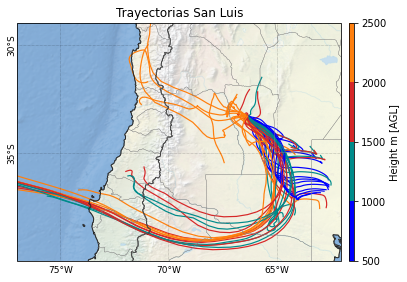

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import numpy as np
import cartopy.io.shapereader as shpreader
from osgeo import gdal
from rasterio.plot import show
from rasterio.windows import Window
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import rasterio

# Define map boundaries
mapcorners = [-77, -62, -40, -29]

# Create the figure and axes with Plate Carrée projection
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='k', alpha=0.5, linestyle=':')
gl.ylocator = mticker.FixedLocator(np.arange(-90, 90, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))
gl.right_labels = False
gl.left_labels = True
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.bottom_labels = True
gl.xformatter = LONGITUDE_FORMATTER
gl.ylabel_style = {'size': 9, 'rotation': 90, 'ha': 'left'}  # Rotate latitude labels vertically and align left
gl.xlabel_style = {'size': 9}

# Add features to the base map
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')

# Set map extent according to mapcorners
ax.set_extent(mapcorners, crs=ccrs.PlateCarree())

# Define altitude levels and corresponding colors
altitude_levels = [500.0, 1000.0, 1500.0, 2000.0]
colors = ['#0000FF', 'darkcyan', '#d62728', '#ff7f0e']  # Colors for each altitude level

# Plot back trajectories with colors based on altitude levels
for traj in trajgroup:
    altitude0 = traj.data.geometry.apply(lambda p: p.z)[0]
    color_idx = np.abs(np.array(altitude_levels) - altitude0).argmin()  # Find nearest altitude level index
    traj_color = colors[color_idx]  # Select corresponding color
    ax.plot(traj.path.xy[0], traj.path.xy[1], c=traj_color, transform=ccrs.PlateCarree(), linewidth=1.2, zorder=1)

# Create a colormap and labels for the colorbar
cmap = mcolors.ListedColormap(colors)
bounds = np.array(altitude_levels + [altitude_levels[-1]+500])  # Add extra boundary for last label
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Add a vertical colorbar to the plot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable
cb = plt.colorbar(sm, ax=ax, orientation='vertical', aspect=50, pad=0.02, shrink=0.73)
cb.set_label('Height m [AGL]')  # Colorbar label

# Path to the GeoTIFF file to use as base layer
file_path = 'C:/Users/Usuario/Desktop/Pysplit/NaturalEarth capa base/NE2_LR_LC_SR_W_DR.tif'

# Open the GeoTIFF and clip according to mapcorners
with rasterio.open(file_path) as src:
    # Read the pixel window corresponding to defined map boundaries
    window = src.window(*mapcorners)
    clipped_img = src.read(window=window)

    # Get transformation info to convert coordinates to pixels
    transform = src.window_transform(window)

# Display the clipped image on the map
show(clipped_img, transform=transform, ax=ax, zorder=0, alpha=0.4)

# Set title and show figure
ax.set_title("San Luis Trajectories", fontsize=12, color="black")
plt.show()


In [ ]:
# Assuming `trajgroup` is your trajectories object
# Get the first trajectory to inspect its data
traj = trajgroup[0]

# Display the available columns in the trajectory data
print(traj.data.columns)


Index(['Timestep', 'Pressure', 'geometry', 'DateTime', 'Temperature_C',
       'Temperature', 'Mixing_Depth'],
      dtype='object')


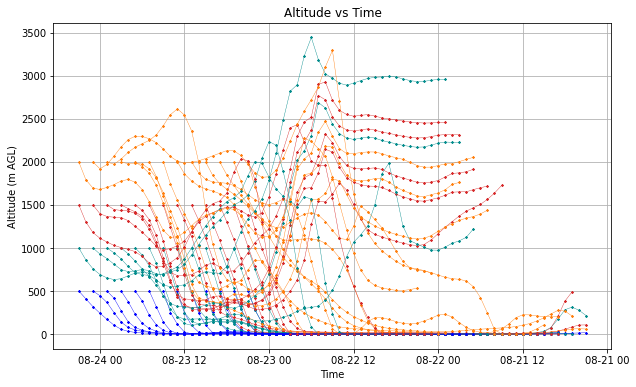

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  # Import map projection if needed

# Assuming `trajgroup` is your trajectories object
altitudes_meters = []
hours = []
traj_indices = []  # List to store start and end indices for each trajectory

for idx, traj in enumerate(trajgroup):
    # Get the altitudes of each point in the trajectory (assuming 'z' is the altitude coordinate)
    altitudes = [geom.z for geom in traj.data['geometry']]
    altitudes_meters.extend(altitudes)  # Append altitudes to the master list

    # Get the hour of each point in the trajectory
    hours.extend(traj.data['DateTime'].tolist())  # Assuming 'DateTime' is the column with datetime info

    # Store start and end indices of each trajectory
    traj_indices.append((len(altitudes_meters) - len(altitudes), len(altitudes_meters) - 1))

# Create a DataFrame with altitude (meters) and datetime
data = pd.DataFrame({'Altitude (meters)': altitudes_meters, 'DateTime': hours})

# Convert DateTime column to datetime type if it's not already
data['DateTime'] = pd.to_datetime(data['DateTime'])

# Plot Altitude vs Time
plt.figure(figsize=(10, 6))

# Define color mapping based on initial altitudes
color_dict = {500.0: '#0000FF', 1000.0: 'darkcyan', 1500.0: '#d62728', 2000.0: '#ff7f0e'}

# Iterate over start and end indices to plot each trajectory segment
for start_idx, end_idx in traj_indices:
    sub_data = data.iloc[start_idx:end_idx + 1]  # Subset data for current trajectory

    # Get initial altitude of the trajectory
    altitude0 = sub_data['Altitude (meters)'].iloc[0]

    # Assign color based on initial altitude using the defined color mapping
    traj_color = color_dict.get(altitude0, 'gray')

    # Plot trajectory without connecting lines between trajectories, using assigned color
    plt.plot(sub_data['DateTime'], sub_data['Altitude (meters)'], marker='*', c=traj_color, linewidth=0.4, markersize=2)

plt.title('Altitude vs Time')
plt.xlabel('Time')
plt.ylabel('Altitude (m AGL)')
plt.grid(True)
plt.xticks(rotation=0)  # Keep x-axis labels horizontal for better visualization

# Invert x-axis to show dates in descending order
plt.gca().invert_xaxis()

plt.show()
